# Création d'une session Spark

In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
        .appName('Gestion_Logistique')
        .master('local[*]')
        .getOrCreate())

# Chargement des données brutes

In [2]:
df = spark.read.csv('DataCoSupplyChainDataset.csv', header = True, inferSchema = True)

# Détection des colonnes dupliquées

In [ ]:
from pyspark.sql import functions as F

def find_identical_columns(df):
    same_value_pairs = []
    columns = df.columns
    
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col1, col2 = columns[i], columns[j]
            diff_count = df.filter(
                (F.col(col1).isNotNull() & F.col(col2).isNull()) |
                (F.col(col1).isNull() & F.col(col2).isNotNull()) |
                (F.col(col1).cast("string") != F.col(col2).cast("string"))
            ).count()
            
            if diff_count == 0:
                same_value_pairs.append((col1, col2))
                print(f"✓ {col1} == {col2}")
    
    return same_value_pairs

identical_pairs = find_identical_columns(df)
print("\nPairs of columns with identical values:")
for pair in identical_pairs:
    print(pair)


✓ Benefit per order == Order Profit Per Order
✓ Sales per customer == Order Item Total
✓ Category Id == Product Category Id
✓ Customer Email == Customer Password
✓ Customer Id == Order Customer Id
✓ Order Item Cardprod Id == Product Card Id
✓ Order Item Product Price == Product Price

Pairs of columns with identical values:
('Benefit per order', 'Order Profit Per Order')
('Sales per customer', 'Order Item Total')
('Category Id', 'Product Category Id')
('Customer Email', 'Customer Password')
('Customer Id', 'Order Customer Id')
('Order Item Cardprod Id', 'Product Card Id')
('Order Item Product Price', 'Product Price')


# Affichage du schéma des colonnes

In [6]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipping (real): integer (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Sales per customer: double (nullable = true)
 |-- Delivery Status: string (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Category Name: string (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Email: string (nullable = true)
 |-- Customer Fname: string (nullable = true)
 |-- Customer Id: integer (nullable = true)
 |-- Customer Lname: string (nullable = true)
 |-- Customer Password: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Street: string (nullable = true)
 |-- Customer Zipcode: integer (nullable = true)
 |-- Department Id: integer (nullable = 

# Affichage d'un extrait des données

In [7]:
df.show(5)

+--------+------------------------+-----------------------------+-----------------+------------------+----------------+------------------+-----------+--------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+--------------------+----------------+-------------+---------------+-----------+------------+------------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+------+----------------+----------------------+--------------+---------------+---------------+-------------+---------------+-------------------+-------------------+--------------------+------------+-------------+--------------+--------------------------+--------------+
|    Type|Days for shipping (real)|Days for shipment (scheduled)|Benefit per order|Sales per c

# Affichage des Statistiques descriptives globales

In [8]:
df.describe().show()

+-------+--------+------------------------+-----------------------------+------------------+------------------+----------------+-------------------+------------------+------------------+-------------+----------------+--------------+--------------+-----------------+--------------+-----------------+----------------+------------------+---------------+-----------------+-----------------+---------------+-----------------+------------------+------+--------------+-------------+-----------------+-----------------------+-----------------+----------------------+-------------------+------------------------+------------------+------------------------+-----------------------+-------------------+------------------+------------------+----------------------+--------------+--------------+---------------+------------------+-----------------+-------------------+-------------------+--------------------+--------------------+------------------+--------------+--------------------------+--------------+
|summa

# Identification des valeurs manquantes

In [10]:
from pyspark.sql import functions as F

missing_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_counts.show()

+----+------------------------+-----------------------------+-----------------+------------------+---------------+------------------+-----------+-------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+---------------+----------------+-------------+---------------+--------+---------+------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+-----+----------------+----------------------+------------+-----------+------------+-------------+---------------+-------------------+-------------------+-------------+------------+-------------+--------------+--------------------------+-------------+
|Type|Days for shipping (real)|Days for shipment (scheduled)|Benefit per order|Sales per customer|Delivery Status|Late_delivery_risk|Ca

# Détection des outliers

In [12]:
numeric_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price',
    'Latitude',
    'Longitude'
]

for col in numeric_cols:
   
    Q1, Q3 = df.approxQuantile(col, [0.25, 0.75], 0)
    IQR = Q3 - Q1

    
    lower= Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df.filter((df[col] < lower) | (df[col] > upper)).count()

    print(f"{col}: {outlier_count} outliers")

Days for shipping (real): 0 outliers
Days for shipment (scheduled): 0 outliers
Benefit per order: 18942 outliers
Sales per customer: 1943 outliers
Order Item Discount: 7537 outliers
Order Item Discount Rate: 0 outliers
Order Item Product Price: 2048 outliers
Order Item Profit Ratio: 17300 outliers
Order Item Quantity: 0 outliers
Sales: 488 outliers
Order Item Total: 1943 outliers
Order Profit Per Order: 18942 outliers
Product Price: 2048 outliers
Latitude: 9 outliers
Longitude: 1414 outliers


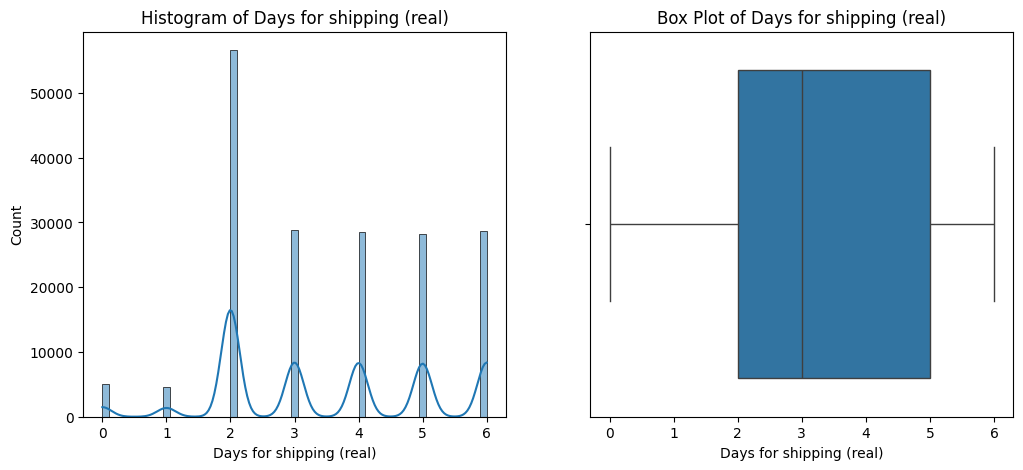

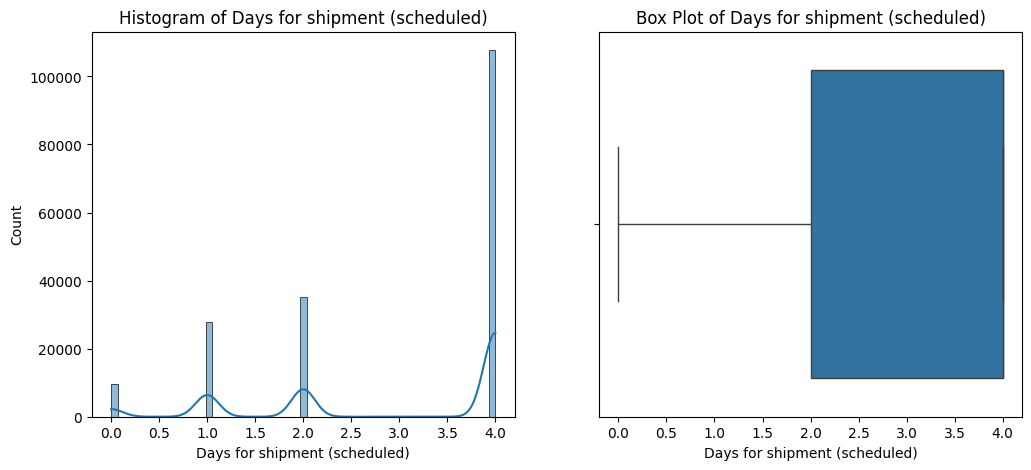

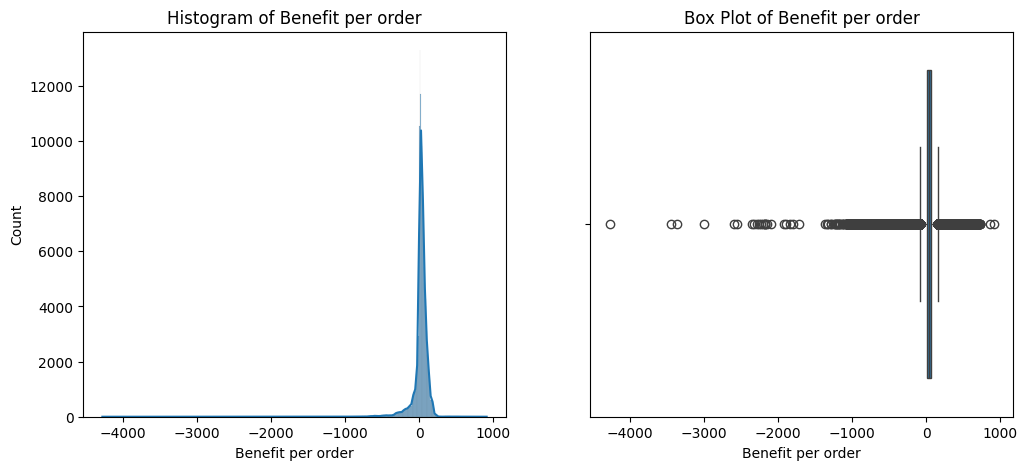

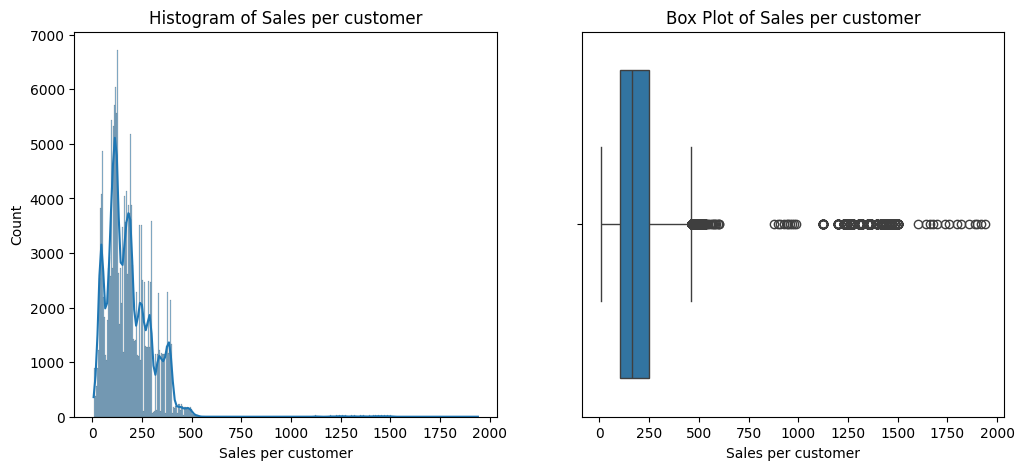

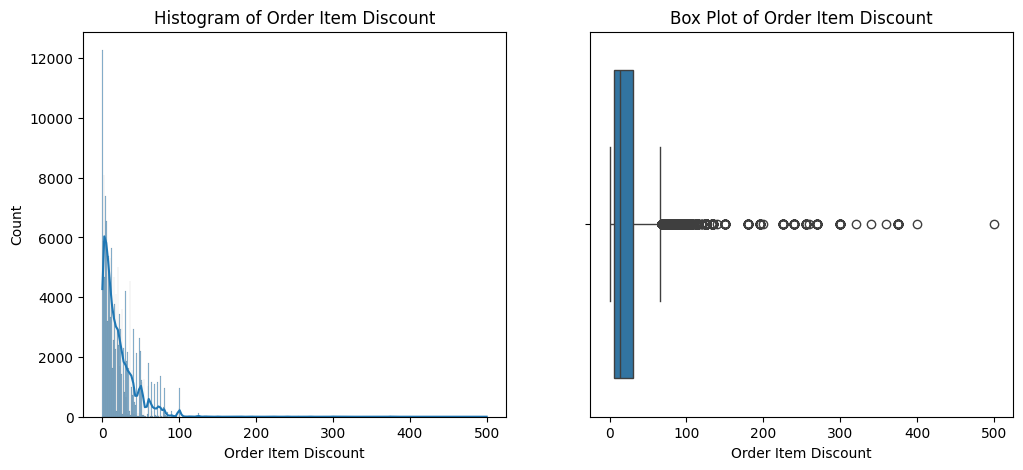

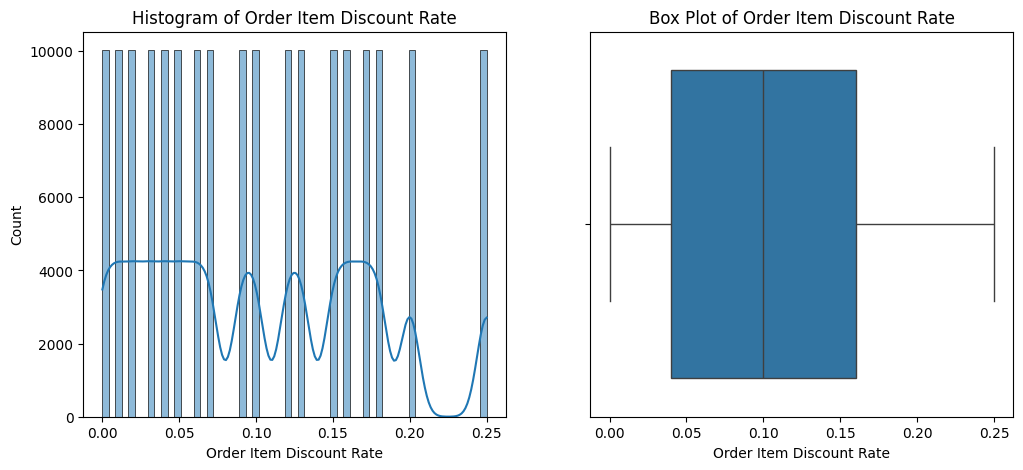

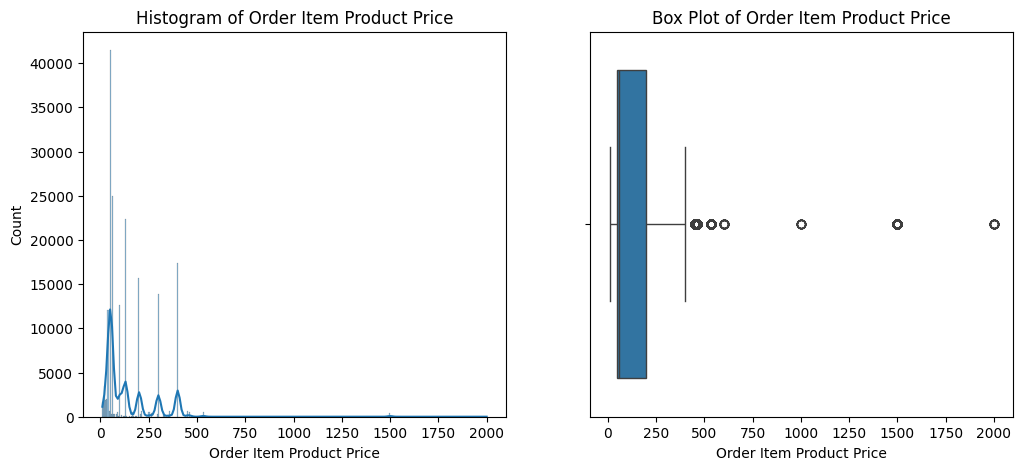

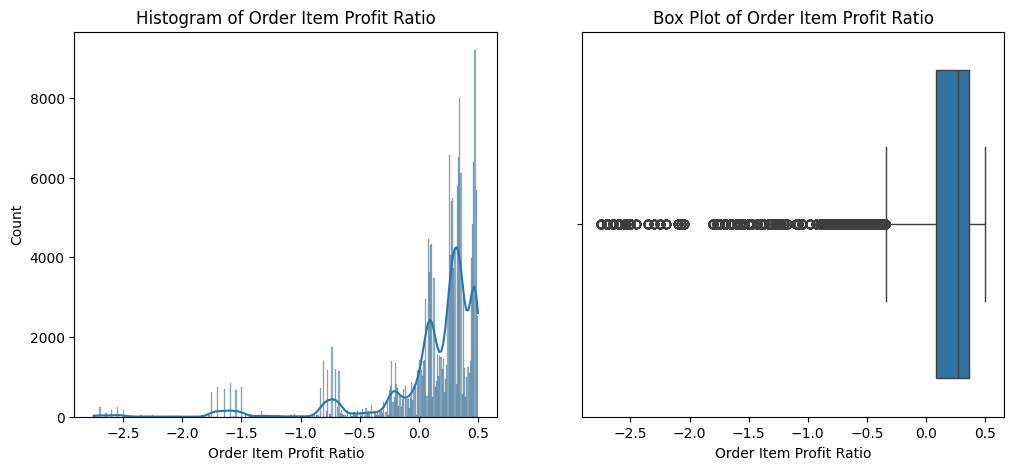

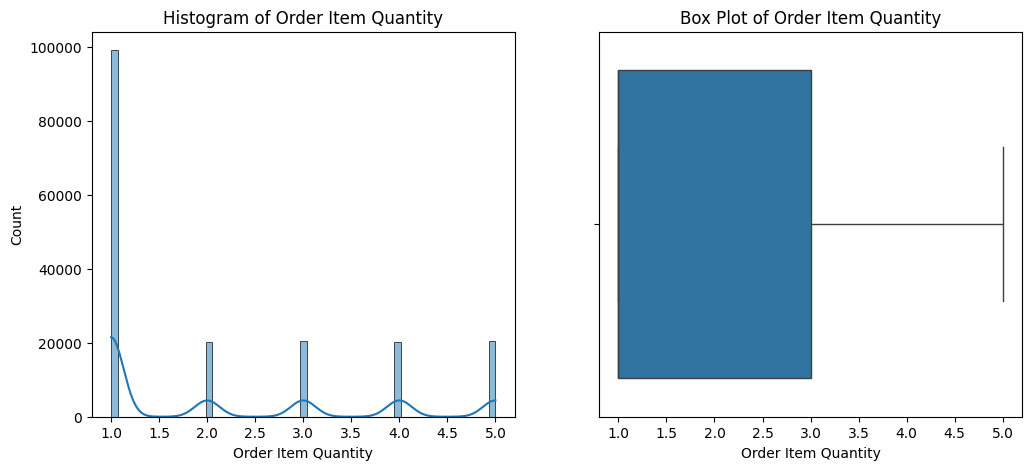

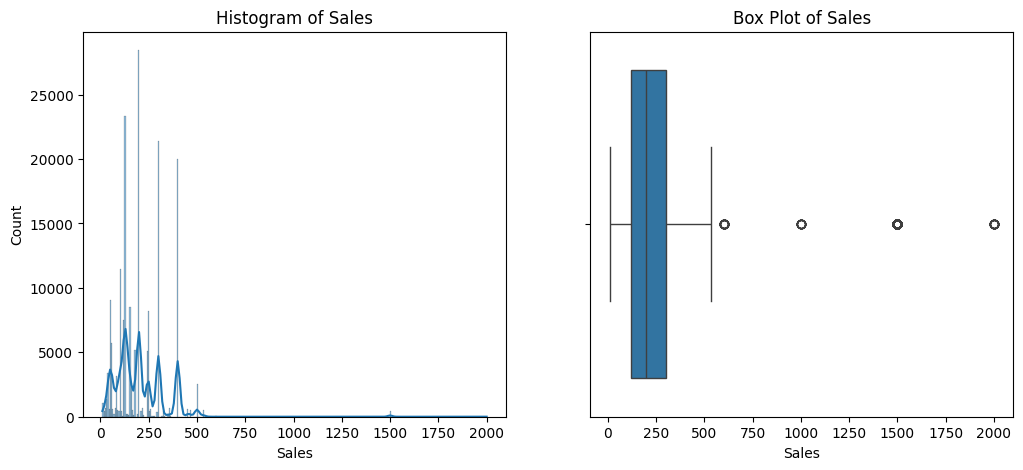

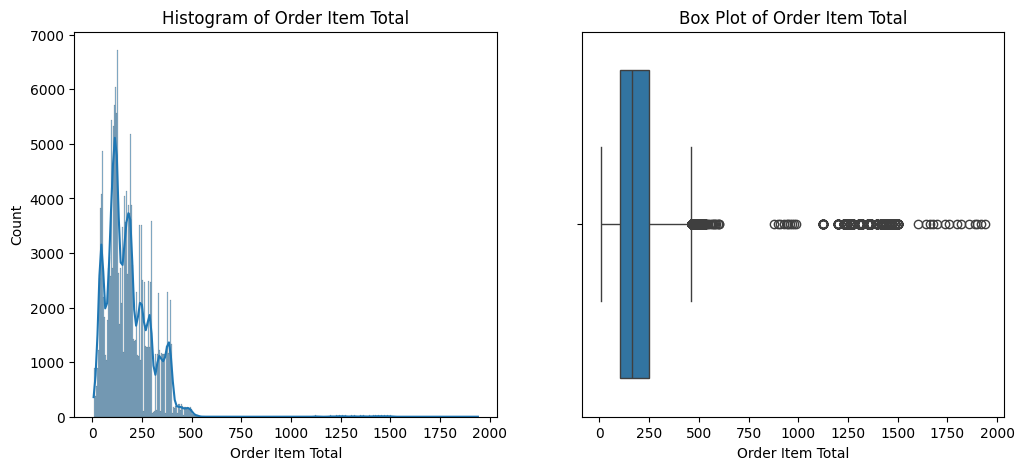

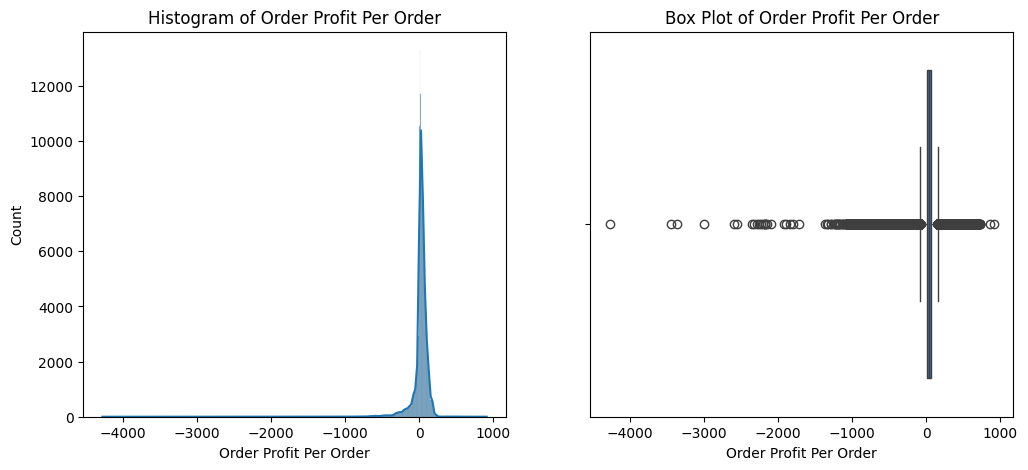

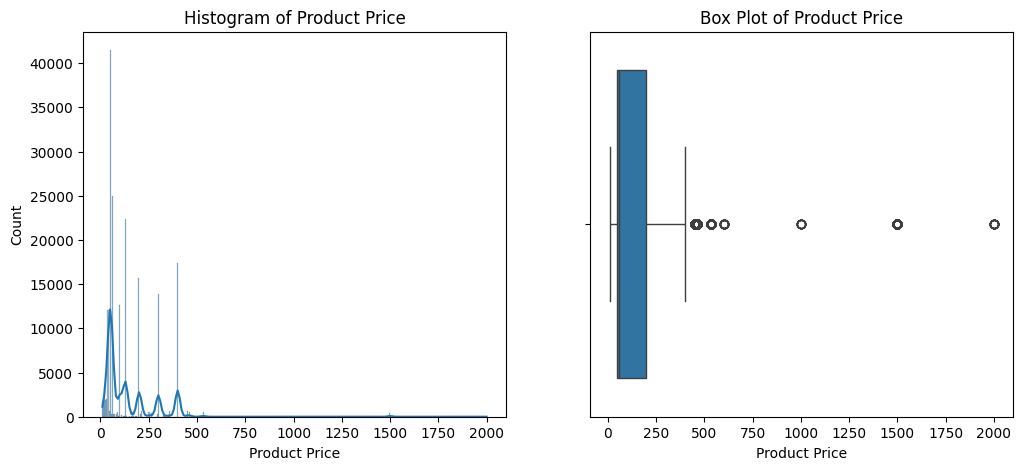

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Your list of columns to check for outliers
continuous_and_discrete_features = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price'
]

# Assuming 'df' is your PySpark DataFrame
for col in continuous_and_discrete_features:
    
    #
    # THE FIX IS HERE: Select the column and convert ONLY that column to pandas
    #
    pd_series = df.select(col).toPandas()[col]
    #
    #

    plt.figure(figsize=(12, 5))
    
    # Plot 1: Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(pd_series, kde=True)
    plt.title(f'Histogram of {col}')
    
    # Plot 2: Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=pd_series)
    plt.title(f'Box Plot of {col}')
    
    plt.show()        

In [ ]:
#columns to drop: duplicates, product description, product status, Customer Email, Customer Password

In [ ]:
#columns to add: is_zip_code_missing, city_risk_encoded, state_risk_encoded, 